In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import io

from itertools import islice
from datasets import load_dataset, Audio

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("EXP-04: Multi-Sample VAD Evaluation")

In [2]:
dataset = load_dataset(
    "guynich/librispeech_asr_test_vad",
    split="test.clean",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

samples = list(islice(dataset, 30))

print("Yüklenen kayıt sayısı:", len(samples))

for i, sample in enumerate(samples[:5]):
    print(
        f"{i + 1}. {sample['file']} | "
        f"Speaker ID: {sample['speaker_id']}"
    )

Yüklenen kayıt sayısı: 30
1. 6930-75918-0000.flac | Speaker ID: 6930
2. 6930-75918-0001.flac | Speaker ID: 6930
3. 6930-75918-0002.flac | Speaker ID: 6930
4. 6930-75918-0003.flac | Speaker ID: 6930
5. 6930-75918-0004.flac | Speaker ID: 6930


In [3]:
def decode_audio(sample):

    audio_data = sample["audio"]

    if audio_data["bytes"] is not None:
        signal, sr = sf.read(
            io.BytesIO(audio_data["bytes"])
        )
    else:
        signal, sr = sf.read(
            audio_data["path"]
        )

    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    return signal, sr


records = []

for sample in samples:

    signal, sr = decode_audio(sample)

    records.append({
        "file": sample["file"],
        "speaker_id": sample["speaker_id"],
        "signal": signal,
        "sr": sr,
        "reference": np.asarray(
            sample["speech"],
            dtype=int
        ),
        "confidence": np.asarray(
            sample["confidence"],
            dtype=int
        )
    })

print("Çözümlenen kayıt sayısı:", len(records))

Çözümlenen kayıt sayısı: 30


In [4]:
timing_data = []

for record in records:

    duration = len(record["signal"]) / record["sr"]

    label_count = len(record["reference"])

    timing_data.append({
        "File": record["file"],
        "Duration": duration,
        "Label Count": label_count,
        "Average Label Duration (ms)":
            duration / label_count * 1000,
        "Expected 32ms Labels":
            int(np.ceil(duration / 0.032)),
        "Difference":
            label_count - int(
                np.ceil(duration / 0.032)
            )
    })

timing_df = pd.DataFrame(timing_data)

print(timing_df.to_string(index=False))

print("\nOrtalama etiket süresi (ms):")
print(
    timing_df["Average Label Duration (ms)"].mean()
)

print("\nEtiket sayısı farklarının dağılımı:")
print(
    timing_df["Difference"].value_counts().sort_index()
)

                File  Duration  Label Count  Average Label Duration (ms)  Expected 32ms Labels  Difference
6930-75918-0000.flac  3.505000          109                    32.155963                   110          -1
6930-75918-0001.flac 14.225000          444                    32.038288                   445          -1
6930-75918-0002.flac  5.025000          157                    32.006369                   158          -1
6930-75918-0003.flac 23.315000          728                    32.026099                   729          -1
6930-75918-0004.flac 11.065000          345                    32.072464                   346          -1
6930-75918-0005.flac 13.160000          411                    32.019465                   412          -1
6930-75918-0006.flac  5.850000          182                    32.142857                   183          -1
6930-75918-0007.flac  3.315000          103                    32.184466                   104          -1
6930-75918-0008.flac  4.785000       

In [5]:
for record in records:
    duration = len(record["signal"]) / record["sr"]

    expected = int(
        np.floor(duration / 0.032 + 1e-9)
    )

    actual = len(record["reference"])

    print(
        f"{record['file']} | "
        f"Expected: {expected} | "
        f"Actual: {actual} | "
        f"Match: {expected == actual}"
    )

6930-75918-0000.flac | Expected: 109 | Actual: 109 | Match: True
6930-75918-0001.flac | Expected: 444 | Actual: 444 | Match: True
6930-75918-0002.flac | Expected: 157 | Actual: 157 | Match: True
6930-75918-0003.flac | Expected: 728 | Actual: 728 | Match: True
6930-75918-0004.flac | Expected: 345 | Actual: 345 | Match: True
6930-75918-0005.flac | Expected: 411 | Actual: 411 | Match: True
6930-75918-0006.flac | Expected: 182 | Actual: 182 | Match: True
6930-75918-0007.flac | Expected: 103 | Actual: 103 | Match: True
6930-75918-0008.flac | Expected: 149 | Actual: 149 | Match: True
6930-75918-0009.flac | Expected: 227 | Actual: 227 | Match: True
6930-75918-0010.flac | Expected: 94 | Actual: 94 | Match: True
6930-75918-0011.flac | Expected: 99 | Actual: 99 | Match: True
6930-75918-0012.flac | Expected: 60 | Actual: 60 | Match: True
6930-75918-0013.flac | Expected: 91 | Actual: 91 | Match: True
6930-75918-0014.flac | Expected: 526 | Actual: 526 | Match: True
6930-75918-0015.flac | Expected: 

In [6]:
def align_predictions(
    rms_values,
    sr,
    reference,
    frame_ms=25,
    hop_ms=10,
    label_ms=32
):
    frame_length = int(sr * frame_ms / 1000)
    hop_length = int(sr * hop_ms / 1000)

    rms_times = (
        np.arange(len(rms_values)) * hop_length
        + frame_length / 2
    ) / sr

    reference_times = (
        np.arange(len(reference)) + 0.5
    ) * label_ms / 1000

    indices = np.abs(
        rms_times[:, None]
        - reference_times[None, :]
    ).argmin(axis=0)

    return indices

In [7]:
development_records = records[:15]
evaluation_records = records[15:]

print(
    "Development kayıt sayısı:",
    len(development_records)
)

print(
    "Evaluation kayıt sayısı:",
    len(evaluation_records)
)

print(
    "\nDevelopment konuşmacıları:",
    set(
        r["speaker_id"]
        for r in development_records
    )
)

print(
    "Evaluation konuşmacıları:",
    set(
        r["speaker_id"]
        for r in evaluation_records
    )
)

Development kayıt sayısı: 15
Evaluation kayıt sayısı: 15

Development konuşmacıları: {6930}
Evaluation konuşmacıları: {6930}


In [8]:
matches = []

for record in records:
    duration = len(record["signal"]) / record["sr"]
    expected = int(np.floor(duration / 0.032 + 1e-9))
    actual = len(record["reference"])

    matches.append(expected == actual)

print("32 ms kuralıyla eşleşen kayıt:", sum(matches))
print("Toplam kayıt:", len(matches))
print("Tüm kayıtlar eşleşiyor mu?", all(matches))

32 ms kuralıyla eşleşen kayıt: 30
Toplam kayıt: 30
Tüm kayıtlar eşleşiyor mu? True


In [9]:
def add_noise(signal, snr_db, seed=42):

    rng = np.random.default_rng(seed)

    noise = rng.normal(0, 1, len(signal))

    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (
        10 ** (snr_db / 10)
    )

    noise = noise * np.sqrt(
        target_noise_power / noise_power
    )

    return signal + noise

In [10]:
frame_ms = 25
hop_ms = 10

snr_levels = [20, 10, 0]

processed_records = []

for record in records:

    signal = record["signal"]
    sr = record["sr"]

    frame_length = int(sr * frame_ms / 1000)
    hop_length = int(sr * hop_ms / 1000)

    signals = {
        "Clean": signal
    }

    for snr in snr_levels:
        signals[f"{snr} dB"] = add_noise(
            signal,
            snr_db=snr
        )

    rms_results = {}

    for name, audio in signals.items():

        rms_results[name] = librosa.feature.rms(
            y=audio,
            frame_length=frame_length,
            hop_length=hop_length,
            center=False
        )[0]

    rms_times = (
        np.arange(len(rms_results["Clean"])) * hop_length
        + frame_length / 2
    ) / sr

    processed_records.append({
        "file": record["file"],
        "speaker_id": record["speaker_id"],
        "reference": record["reference"],
        "confidence": record["confidence"],
        "rms_results": rms_results,
        "rms_times": rms_times
    })

print("İşlenen kayıt sayısı:", len(processed_records))
print(
    "Toplam ses koşulu:",
    sum(len(r["rms_results"]) for r in processed_records)
)

İşlenen kayıt sayısı: 30
Toplam ses koşulu: 120


In [11]:
development_data = processed_records[:15]
evaluation_data = processed_records[15:]

print("Development:", len(development_data))
print("Evaluation:", len(evaluation_data))

Development: 15
Evaluation: 15


In [12]:
def evaluate_vad(record, condition, threshold):

    rms_values = record["rms_results"][condition]
    rms_times = record["rms_times"]

    reference = record["reference"]
    confidence = record["confidence"]

    reference_times = (
        np.arange(len(reference)) + 0.5
    ) * 0.032

    indices = np.abs(
        rms_times[:, None]
        - reference_times[None, :]
    ).argmin(axis=0)

    prediction = (
        rms_values > threshold
    ).astype(int)

    aligned_prediction = prediction[indices]

    valid = confidence == 1

    y_true = reference[valid]
    y_pred = aligned_prediction[valid]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "Accuracy": accuracy_score(y_true, y_pred),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

In [13]:
fixed_thresholds = [0.005, 0.01, 0.02]

fixed_results = []

for threshold in fixed_thresholds:

    for condition in ["Clean", "20 dB", "10 dB", "0 dB"]:

        metrics = []

        for record in development_data:

            result = evaluate_vad(
                record,
                condition,
                threshold
            )

            metrics.append(result)

        fixed_results.append({
            "Threshold": threshold,
            "Condition": condition,
            "Mean Precision": np.mean(
                [m["Precision"] for m in metrics]
            ),
            "Mean Recall": np.mean(
                [m["Recall"] for m in metrics]
            ),
            "Mean F1": np.mean(
                [m["F1"] for m in metrics]
            ),
            "Total FP": sum(
                m["FP"] for m in metrics
            ),
            "Total FN": sum(
                m["FN"] for m in metrics
            )
        })

fixed_df = pd.DataFrame(fixed_results)

print(
    fixed_df.round(3).to_string(index=False)
)

 Threshold Condition  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN
     0.005     Clean           0.949        0.941    0.944       111       183
     0.005     20 dB           0.922        0.965    0.942       170       101
     0.005     10 dB           0.844        1.000    0.911       352         0
     0.005      0 dB           0.844        1.000    0.911       352         0
     0.010     Clean           0.992        0.830    0.903        17       517
     0.010     20 dB           0.990        0.843    0.910        22       472
     0.010     10 dB           0.902        0.974    0.934       258        46
     0.010      0 dB           0.844        1.000    0.911       352         0
     0.020     Clean           0.997        0.583    0.734         4      1245
     0.020     20 dB           0.997        0.590    0.739         4      1222
     0.020     10 dB           0.997        0.657    0.790         5       998
     0.020      0 dB           0.844        1.000   

In [14]:
def calculate_adaptive_threshold(
    rms_values,
    rms_times,
    alpha,
    noise_duration=0.5
):

    noise_frames = rms_values[
        rms_times < noise_duration
    ]

    noise_energy = np.mean(noise_frames)

    threshold = alpha * noise_energy

    return threshold

In [15]:
alpha_values = [1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

conditions = ["Clean", "20 dB", "10 dB", "0 dB"]

adaptive_results = []

for alpha in alpha_values:

    for condition in conditions:

        metrics = []

        for record in development_data:

            rms_values = record["rms_results"][condition]
            rms_times = record["rms_times"]

            threshold = calculate_adaptive_threshold(
                rms_values,
                rms_times,
                alpha=alpha
            )

            result = evaluate_vad(
                record,
                condition,
                threshold
            )

            metrics.append(result)

        adaptive_results.append({
            "Alpha": alpha,
            "Condition": condition,

            "Mean Precision": np.mean([
                m["Precision"] for m in metrics
            ]),

            "Mean Recall": np.mean([
                m["Recall"] for m in metrics
            ]),

            "Mean F1": np.mean([
                m["F1"] for m in metrics
            ]),

            "Total FP": sum(
                m["FP"] for m in metrics
            ),

            "Total FN": sum(
                m["FN"] for m in metrics
            )
        })

adaptive_df = pd.DataFrame(adaptive_results)

print(
    adaptive_df.round(3).to_string(index=False)
)

 Alpha Condition  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN
   1.0     Clean           0.958        0.739    0.813        56       913
   1.0     20 dB           0.960        0.730    0.808        49       941
   1.0     10 dB           0.965        0.704    0.790        40      1048
   1.0      0 dB           0.953        0.665    0.750        54      1197
   1.2     Clean           0.969        0.688    0.777        36      1104
   1.2     20 dB           0.976        0.675    0.772        28      1152
   1.2     10 dB           0.997        0.616    0.737         3      1342
   1.2      0 dB           0.999        0.410    0.564         1      1981
   1.5     Clean           0.983        0.627    0.732        19      1344
   1.5     20 dB           0.994        0.607    0.723         6      1412
   1.5     10 dB           0.999        0.523    0.657         1      1692
   1.5      0 dB           1.000        0.238    0.372         0      2491
   2.0     Clean         

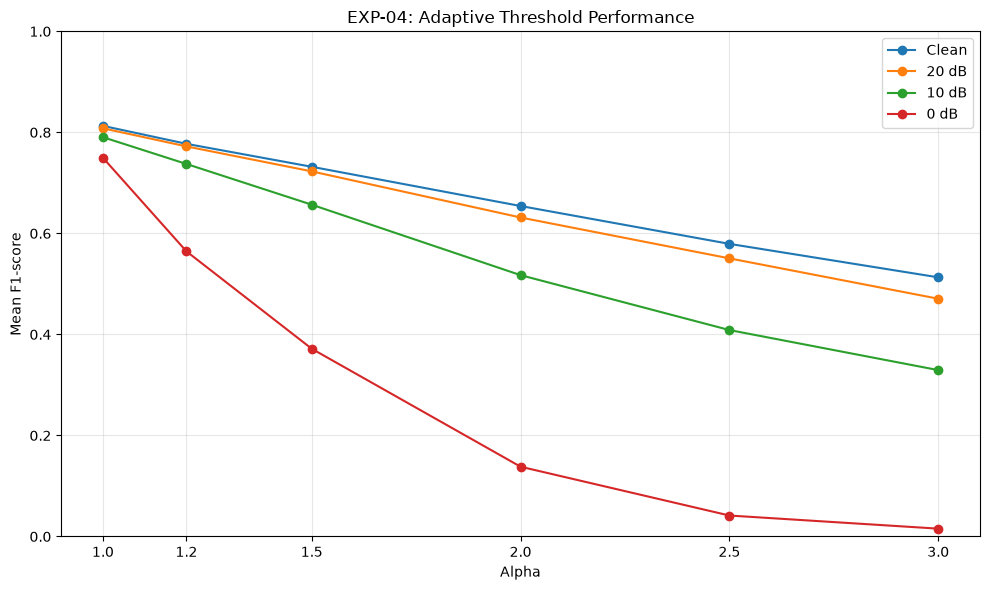

In [16]:
plt.figure(figsize=(10, 6))

for condition in conditions:

    subset = adaptive_df[
        adaptive_df["Condition"] == condition
    ]

    plt.plot(
        subset["Alpha"],
        subset["Mean F1"],
        marker="o",
        label=condition
    )

plt.xlabel("Alpha")
plt.ylabel("Mean F1-score")

plt.title(
    "EXP-04: Adaptive Threshold Performance"
)

plt.ylim(0, 1)
plt.xticks(alpha_values)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
noise_analysis = []

for record in development_data:

    reference = record["reference"]

    # 0.5 saniye / 0.032 saniye ≈ 16 etiket
    first_labels = reference[:16]

    speech_ratio = np.mean(first_labels)

    noise_analysis.append({
        "File": record["file"],
        "Speech Ratio (First 0.5s)": speech_ratio,
        "Speech Labels": np.sum(first_labels),
        "Total Labels": len(first_labels)
    })

noise_df = pd.DataFrame(noise_analysis)

print(
    noise_df.round(3).to_string(index=False)
)

print(
    "\nİlk 0.5 saniyesinde konuşma bulunan kayıt:",
    (noise_df["Speech Labels"] > 0).sum()
)

                File  Speech Ratio (First 0.5s)  Speech Labels  Total Labels
6930-75918-0000.flac                      0.000              0            16
6930-75918-0001.flac                      0.438              7            16
6930-75918-0002.flac                      0.500              8            16
6930-75918-0003.flac                      0.500              8            16
6930-75918-0004.flac                      0.125              2            16
6930-75918-0005.flac                      0.500              8            16
6930-75918-0006.flac                      0.062              1            16
6930-75918-0007.flac                      0.188              3            16
6930-75918-0008.flac                      0.000              0            16
6930-75918-0009.flac                      0.312              5            16
6930-75918-0010.flac                      0.062              1            16
6930-75918-0011.flac                      0.500              8            16

In [18]:
def calculate_percentile_threshold(
    rms_values,
    alpha,
    percentile=10
):

    noise_floor = np.percentile(
        rms_values,
        percentile
    )

    threshold = alpha * noise_floor

    return threshold

In [19]:
percentile_results = []

alpha_values = [1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

conditions = ["Clean", "20 dB", "10 dB", "0 dB"]

for alpha in alpha_values:

    for condition in conditions:

        metrics = []

        for record in development_data:

            rms_values = record["rms_results"][condition]

            threshold = calculate_percentile_threshold(
                rms_values,
                alpha=alpha,
                percentile=10
            )

            result = evaluate_vad(
                record,
                condition,
                threshold
            )

            metrics.append(result)

        percentile_results.append({
            "Alpha": alpha,
            "Condition": condition,

            "Mean Precision": np.mean([
                m["Precision"] for m in metrics
            ]),

            "Mean Recall": np.mean([
                m["Recall"] for m in metrics
            ]),

            "Mean F1": np.mean([
                m["F1"] for m in metrics
            ]),

            "Total FP": sum(
                m["FP"] for m in metrics
            ),

            "Total FN": sum(
                m["FN"] for m in metrics
            )
        })

percentile_df = pd.DataFrame(
    percentile_results
)

print(
    percentile_df.round(3).to_string(index=False)
)

 Alpha Condition  Mean Precision  Mean Recall  Mean F1  Total FP  Total FN
   1.0     Clean           0.889        0.978    0.928       211        90
   1.0     20 dB           0.889        0.978    0.927       212        92
   1.0     10 dB           0.886        0.972    0.923       218        98
   1.0      0 dB           0.874        0.951    0.907       243       170
   1.2     Clean           0.906        0.966    0.932       173       135
   1.2     20 dB           0.921        0.955    0.935       142       174
   1.2     10 dB           0.973        0.874    0.920        43       424
   1.2      0 dB           0.998        0.553    0.710         2      1446
   1.5     Clean           0.920        0.952    0.932       141       188
   1.5     20 dB           0.948        0.923    0.933        82       288
   1.5     10 dB           0.996        0.767    0.866         7       790
   1.5      0 dB           0.999        0.325    0.487         1      2194
   2.0     Clean         

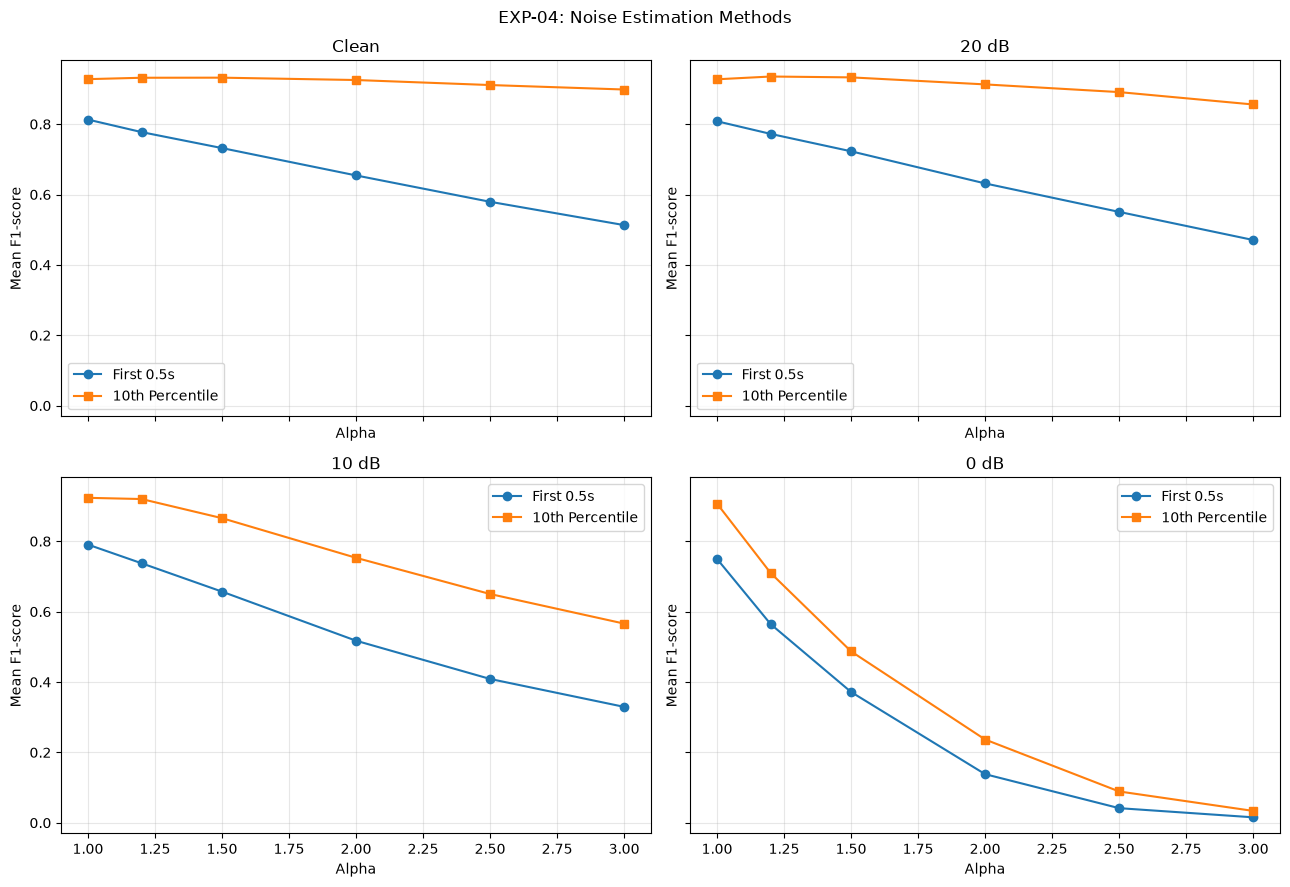

In [20]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 9),
    sharex=True,
    sharey=True
)

for ax, condition in zip(
    axes.flat,
    conditions
):

    old_data = adaptive_df[
        adaptive_df["Condition"] == condition
    ]

    new_data = percentile_df[
        percentile_df["Condition"] == condition
    ]

    ax.plot(
        old_data["Alpha"],
        old_data["Mean F1"],
        marker="o",
        label="First 0.5s"
    )

    ax.plot(
        new_data["Alpha"],
        new_data["Mean F1"],
        marker="s",
        label="10th Percentile"
    )

    ax.set_title(condition)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Mean F1-score")

    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    "EXP-04: Noise Estimation Methods"
)

plt.tight_layout()
plt.show()

In [21]:
selected_methods = {
    "Fixed": {
        "threshold": 0.005
    },
    "First 0.5s": {
        "alpha": 1.0
    },
    "10th Percentile": {
        "alpha": 1.0,
        "percentile": 10
    }
}

conditions = ["Clean", "20 dB", "10 dB", "0 dB"]

final_results = []

for method, params in selected_methods.items():

    for condition in conditions:

        metrics = []

        for record in evaluation_data:

            rms_values = record["rms_results"][condition]
            rms_times = record["rms_times"]

            if method == "Fixed":

                threshold = params["threshold"]

            elif method == "First 0.5s":

                threshold = calculate_adaptive_threshold(
                    rms_values,
                    rms_times,
                    alpha=params["alpha"]
                )

            else:

                threshold = calculate_percentile_threshold(
                    rms_values,
                    alpha=params["alpha"],
                    percentile=params["percentile"]
                )

            result = evaluate_vad(
                record,
                condition,
                threshold
            )

            metrics.append(result)

        tp = sum(m["TP"] for m in metrics)
        tn = sum(m["TN"] for m in metrics)
        fp = sum(m["FP"] for m in metrics)
        fn = sum(m["FN"] for m in metrics)

        final_results.append({
            "Method": method,
            "Condition": condition,

            "Mean Precision": np.mean([
                m["Precision"] for m in metrics
            ]),

            "Mean Recall": np.mean([
                m["Recall"] for m in metrics
            ]),

            "Mean F1": np.mean([
                m["F1"] for m in metrics
            ]),

            "Total TP": tp,
            "Total TN": tn,
            "Total FP": fp,
            "Total FN": fn,

            "Micro Precision": (
                tp / (tp + fp)
                if tp + fp > 0 else 0
            ),

            "Micro Recall": (
                tp / (tp + fn)
                if tp + fn > 0 else 0
            ),

            "Micro F1": (
                2 * tp / (2 * tp + fp + fn)
                if 2 * tp + fp + fn > 0 else 0
            )
        })

final_df = pd.DataFrame(final_results)

print(
    final_df.round(3).to_string(index=False)
)

         Method Condition  Mean Precision  Mean Recall  Mean F1  Total TP  Total TN  Total FP  Total FN  Micro Precision  Micro Recall  Micro F1
          Fixed     Clean           0.959        0.941    0.949      2389       194        84       149            0.966         0.941     0.954
          Fixed     20 dB           0.944        0.966    0.954      2447       157       121        91            0.953         0.964     0.958
          Fixed     10 dB           0.884        1.000    0.937      2538         0       278         0            0.901         1.000     0.948
          Fixed      0 dB           0.884        1.000    0.937      2538         0       278         0            0.901         1.000     0.948
     First 0.5s     Clean           0.986        0.702    0.800      1844       245        33       694            0.982         0.727     0.835
     First 0.5s     20 dB           0.992        0.690    0.794      1804       261        17       734            0.991         0

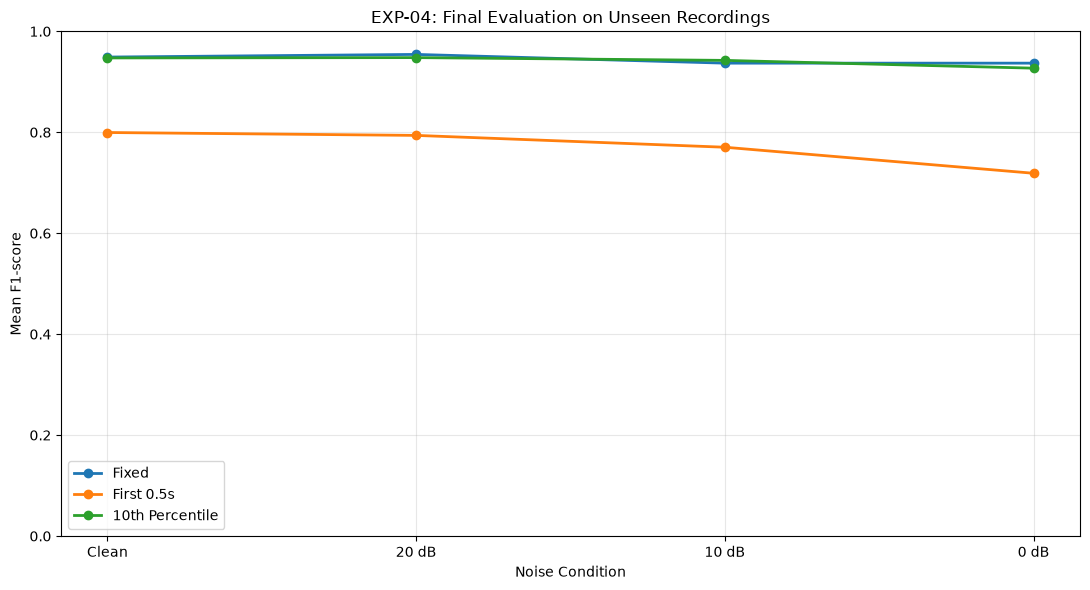

In [22]:
plt.figure(figsize=(11, 6))

for method in selected_methods:

    subset = final_df[
        final_df["Method"] == method
    ]

    plt.plot(
        subset["Condition"],
        subset["Mean F1"],
        marker="o",
        linewidth=2,
        label=method
    )

plt.title(
    "EXP-04: Final Evaluation on Unseen Recordings"
)

plt.xlabel("Noise Condition")
plt.ylabel("Mean F1-score")

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

final_df.to_csv(
    results_dir / "exp04_final_results.csv",
    index=False
)

plt.savefig(
    results_dir / "figures" / "exp04_final_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Sonuçlar kaydedildi.")

Sonuçlar kaydedildi.


<Figure size 640x480 with 0 Axes>

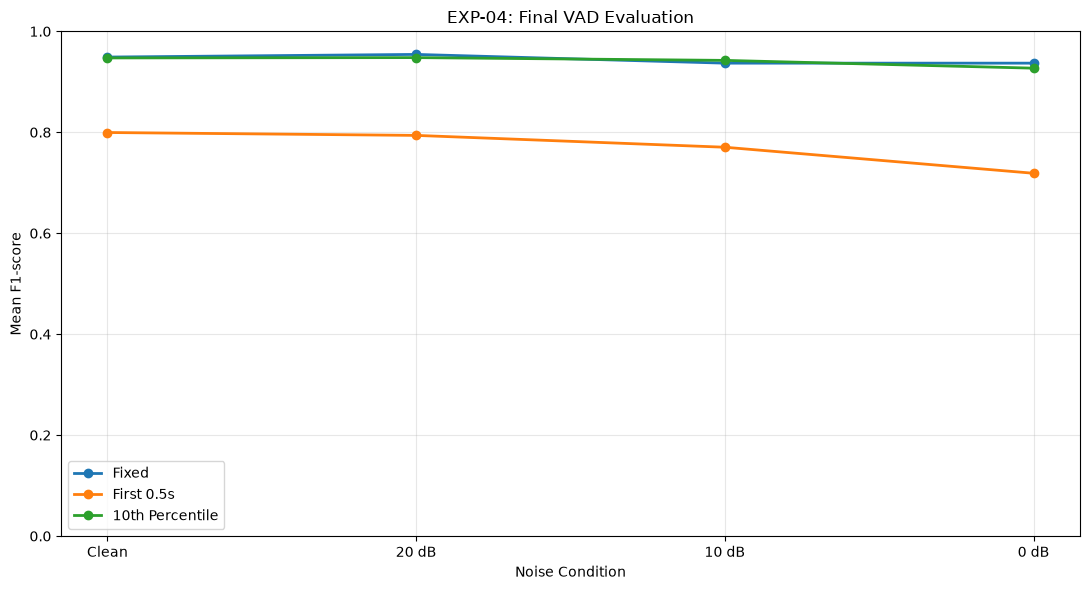

EXP-04 sonuçları kaydedildi.


In [24]:
from pathlib import Path

results_dir = Path("../results")
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

final_df.to_csv(
    results_dir / "exp04_final_results.csv",
    index=False
)

# Son karşılaştırma grafiğini yeniden oluştur.
fig, ax = plt.subplots(figsize=(11, 6))

for method in selected_methods:
    subset = final_df[final_df["Method"] == method]

    ax.plot(
        subset["Condition"],
        subset["Mean F1"],
        marker="o",
        linewidth=2,
        label=method
    )

ax.set_title("EXP-04: Final VAD Evaluation")
ax.set_xlabel("Noise Condition")
ax.set_ylabel("Mean F1-score")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    figures_dir / "exp04_final_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("EXP-04 sonuçları kaydedildi.")